# Part 3: Baseline Models
- **Random Forest** ใช้ MFCC features (80-dim)
- **2D CNN** ใช้ Mel-Spectrogram (1, 128, 1293)
- Evaluate ด้วย F1-score + Confusion Matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR      = '/content/drive/MyDrive/music-genre'
DATA_DIR      = f'{BASE_DIR}/data'
PROCESSED_DIR = f'{DATA_DIR}/processed'
MEL_DIR       = f'{PROCESSED_DIR}/mel'
MFCC_DIR      = f'{PROCESSED_DIR}/mfcc'
MODEL_DIR     = f'{BASE_DIR}/models'
os.makedirs(MODEL_DIR, exist_ok=True)
print('Ready.')

Mounted at /content/drive
Ready.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import joblib
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 8
print(f'Device: {DEVICE}')

# โหลด label map
label_map = pd.read_csv(f'{PROCESSED_DIR}/label_map.csv')
idx2genre = dict(zip(label_map['label'], label_map['genre']))
GENRES    = [idx2genre[i] for i in range(NUM_CLASSES)]
print('Genres:', GENRES)

Device: cuda
Genres: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


## Part A: Random Forest (MFCC features)

In [ ]:
def load_mfcc_split(df: pd.DataFrame):
    """โหลด MFCC features และ labels สำหรับ split นึง"""
    X, y, valid_ids = [], [], []
    for _, row in df.iterrows():
        path = Path(MFCC_DIR) / f'{row["track_id"]}.npy'
        if path.exists():
            X.append(np.load(str(path)))
            y.append(row['label'])
            valid_ids.append(row['track_id'])
    return np.array(X), np.array(y)

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

print('Loading MFCC features...')
X_train, y_train = load_mfcc_split(train_df)
X_val,   y_val   = load_mfcc_split(val_df)
X_test,  y_test  = load_mfcc_split(test_df)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Loading MFCC features...
Train: (6397, 80) | Val: (798, 80) | Test: (799, 80)


In [ ]:
# Train Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf.fit(X_train, y_train)

# Evaluate
y_pred_val  = rf.predict(X_val)
y_pred_test = rf.predict(X_test)

f1_val  = f1_score(y_val,  y_pred_val,  average='macro')
f1_test = f1_score(y_test, y_pred_test, average='macro')

print(f'\n[Random Forest]')
print(f'  Val  F1 (macro): {f1_val:.4f}')
print(f'  Test F1 (macro): {f1_test:.4f}')
print('\nClassification Report (Test):')
print(classification_report(y_test, y_pred_test, target_names=GENRES))

# บันทึก model
joblib.dump(rf, f'{MODEL_DIR}/random_forest.pkl')
print(f'Saved → {MODEL_DIR}/random_forest.pkl')

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   18.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished



[Random Forest]
  Val  F1 (macro): 0.4714
  Test F1 (macro): 0.5093

Classification Report (Test):
               precision    recall  f1-score   support

   Electronic       0.45      0.46      0.46        99
 Experimental       0.63      0.38      0.47       100
         Folk       0.60      0.67      0.63       100
      Hip-Hop       0.53      0.61      0.56       100
 Instrumental       0.54      0.52      0.53       100
International       0.53      0.53      0.53       100
          Pop       0.35      0.26      0.30       100
         Rock       0.51      0.70      0.59       100

     accuracy                           0.52       799
    macro avg       0.52      0.52      0.51       799
 weighted avg       0.52      0.52      0.51       799

Saved → /content/drive/MyDrive/music-genre/models/random_forest.pkl


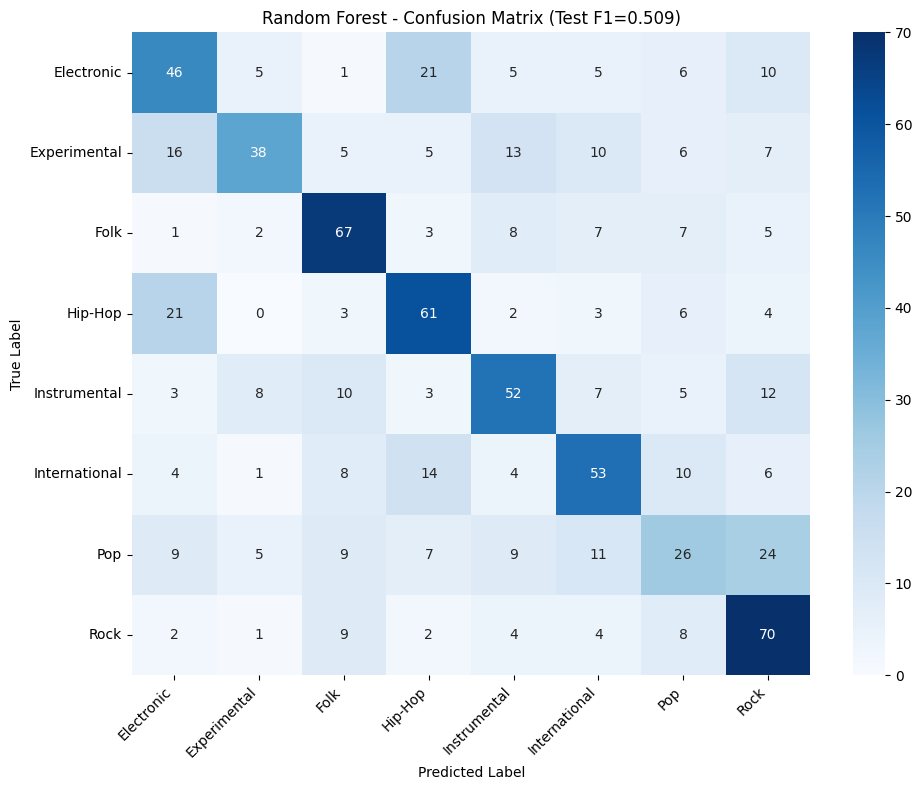

In [ ]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title(f'Random Forest - Confusion Matrix (Test F1={f1_test:.3f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cm_random_forest.png', dpi=100)
plt.show()

## Part B: 2D CNN Baseline (Mel-Spectrogram)

In [ ]:
class MelDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mel_dir: str):
        # กรองเฉพาะ track ที่มีไฟล์ .pt
        records = []
        for _, row in df.iterrows():
            path = Path(mel_dir) / f'{row["track_id"]}.pt'
            if path.exists():
                records.append((str(path), row['label']))
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, label = self.records[idx]
        mel = torch.load(path)          # (1, 128, T)
        # Normalize ให้ mean=0, std=1 ต่อ sample
        mel = (mel - mel.mean()) / (mel.std() + 1e-9)
        return mel, label


BATCH_SIZE = 32
train_loader = DataLoader(MelDataset(train_df, MEL_DIR), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(MelDataset(val_df,   MEL_DIR), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(MelDataset(test_df,  MEL_DIR), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 200 | Val: 25 | Test: 25


In [ ]:
class CNN2DBaseline(nn.Module):
    """2D CNN Baseline — 3 conv blocks + classifier"""
    def __init__(self, num_classes: int = 8):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # (32, 64, T/2)
            nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # (64, 32, T/4)
            nn.Dropout2d(0.1),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),  # (128, 4, 4) คงที่ไม่ว่า input จะยาวแค่ไหน
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = CNN2DBaseline(num_classes=NUM_CLASSES).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

CNN2DBaseline(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.1, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_featu

In [ ]:
# Training setup
EPOCHS    = 30
LR        = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_val_f1 = 0.0


def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for mel, label in loader:
        mel, label = mel.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(mel), label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for mel, label in loader:
        mel, label = mel.to(DEVICE), label.to(DEVICE)
        out = model(mel)
        total_loss += criterion(out, label).item()
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(label.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), f1, all_preds, all_labels


print('Starting training...')
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader)
    val_loss, val_f1, _, _ = evaluate(model, val_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # บันทึก best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), f'{MODEL_DIR}/cnn2d_baseline_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val F1: {val_f1:.4f}')

print(f'\nBest Val F1: {best_val_f1:.4f}')

Starting training...
Epoch 01/30 | Train Loss: 1.8449 | Val Loss: 1.6704 | Val F1: 0.3287
Epoch 05/30 | Train Loss: 1.5633 | Val Loss: 1.4603 | Val F1: 0.4672
Epoch 10/30 | Train Loss: 1.4285 | Val Loss: 1.3431 | Val F1: 0.5040
Epoch 15/30 | Train Loss: 1.3534 | Val Loss: 1.2975 | Val F1: 0.5301
Epoch 20/30 | Train Loss: 1.3037 | Val Loss: 1.2837 | Val F1: 0.5379
Epoch 25/30 | Train Loss: 1.2152 | Val Loss: 1.2268 | Val F1: 0.5621
Epoch 30/30 | Train Loss: 1.1905 | Val Loss: 1.2156 | Val F1: 0.5604

Best Val F1: 0.5706


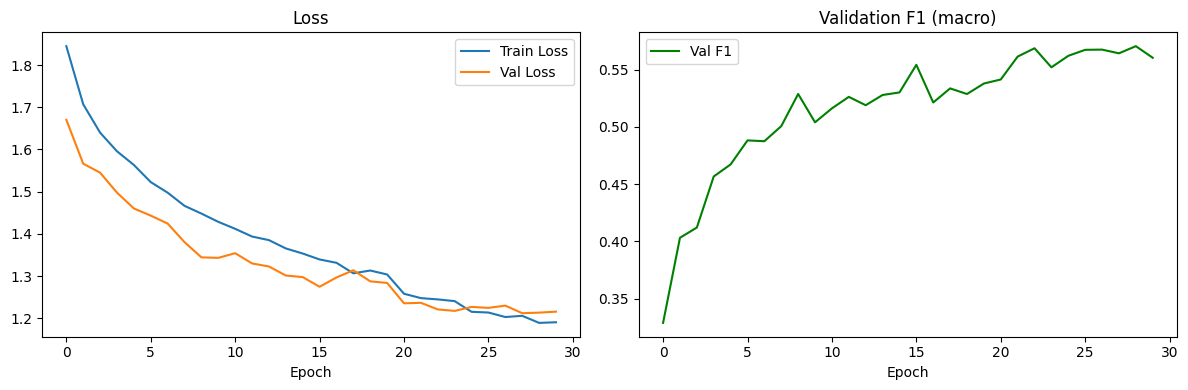

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['val_f1'], label='Val F1', color='green')
ax2.set_title('Validation F1 (macro)')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cnn2d_training_history.png', dpi=100)
plt.show()

In [ ]:
# Evaluate บน Test set ด้วย best model
model.load_state_dict(torch.load(f'{MODEL_DIR}/cnn2d_baseline_best.pt'))
test_loss, test_f1, y_pred_cnn, y_true_cnn = evaluate(model, test_loader)

print(f'[2D CNN Baseline]')
print(f'  Test Loss: {test_loss:.4f}')
print(f'  Test F1 (macro): {test_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=GENRES))

[2D CNN Baseline]
  Test Loss: 1.0888
  Test F1 (macro): 0.6075

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.62      0.71      0.66        99
 Experimental       0.65      0.51      0.57       100
         Folk       0.63      0.75      0.68       100
      Hip-Hop       0.75      0.74      0.74       100
 Instrumental       0.56      0.69      0.62       100
International       0.67      0.73      0.70       100
          Pop       0.39      0.15      0.22       100
         Rock       0.61      0.73      0.67       100

     accuracy                           0.63       799
    macro avg       0.61      0.63      0.61       799
 weighted avg       0.61      0.63      0.61       799



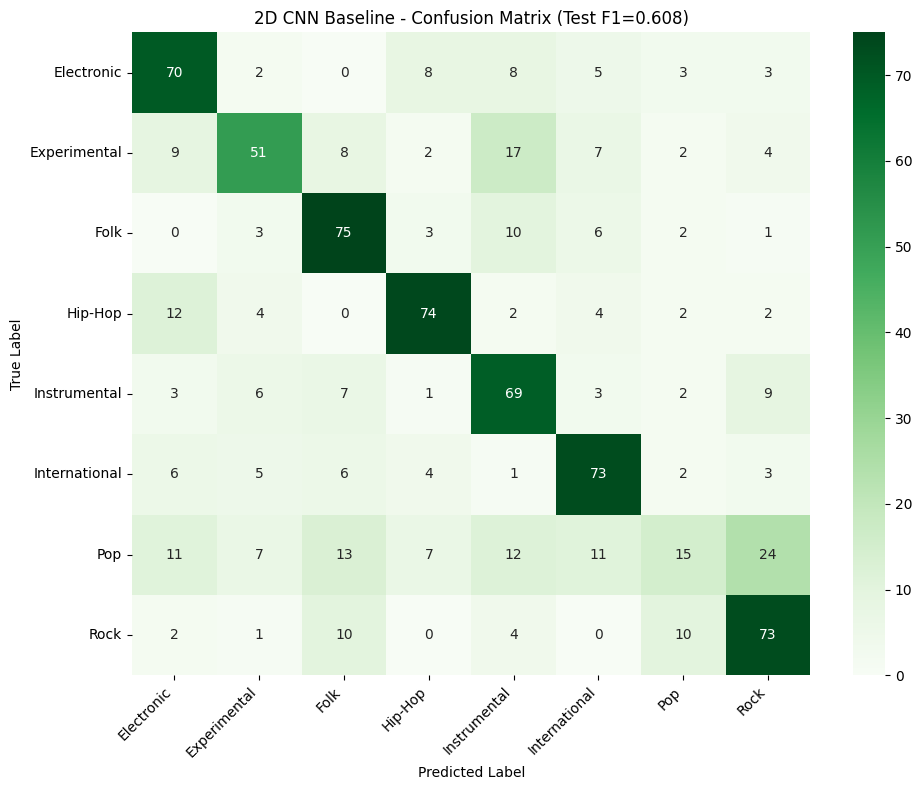

In [ ]:
# Confusion Matrix - 2D CNN
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title(f'2D CNN Baseline - Confusion Matrix (Test F1={test_f1:.3f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cm_cnn2d_baseline.png', dpi=100)
plt.show()

In [ ]:
# สรุปเปรียบเทียบ Baseline ทั้งสอง
print('=' * 40)
print('         BASELINE SUMMARY')
print('=' * 40)
print(f'  Random Forest  Test F1: {f1_test:.4f}')
print(f'  2D CNN         Test F1: {test_f1:.4f}')
print('=' * 40)

         BASELINE SUMMARY
  Random Forest  Test F1: 0.5093
  2D CNN         Test F1: 0.6075
